In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [7]:
df = pd.read_csv("social_media_mental_health_small_dataset.csv")

df.head()

,age,gender,daily_usage_hours,sleep_hours,screen_time,depression_risk
0,24,Male,2.6,5.8,4.2,Low
1,32,Female,5.5,4.6,7.3,Medium
2,28,Male,2.2,6.6,3.6,Low
3,25,Male,5.8,7.8,6.9,Medium
4,24,Female,3.7,5.1,4.9,Low


In [8]:
df.shape

(120, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                120 non-null    int64  
 1   gender             120 non-null    object 
 2   daily_usage_hours  120 non-null    float64
 3   sleep_hours        120 non-null    float64
 4   screen_time        120 non-null    float64
 5   depression_risk    120 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 5.8+ KB


In [10]:
df.describe()

,age,daily_usage_hours,sleep_hours,screen_time
count,120.000000,120.000000,120.000000,120.000000
mean,25.716667,4.740833,6.462500,6.318333
std,4.775961,2.048385,1.498013,2.110557
min,18.000000,1.000000,4.100000,2.300000
25%,21.000000,3.000000,5.175000,4.200000
50%,25.000000,5.000000,6.500000,6.700000
75%,30.000000,6.600000,7.800000,8.025000
max,34.000000,7.900000,9.000000,10.100000


In [11]:
df.isnull().sum()

,0
age,0
gender,0
daily_usage_hours,0
sleep_hours,0
screen_time,0
depression_risk,0


In [12]:
df.fillna(0, inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

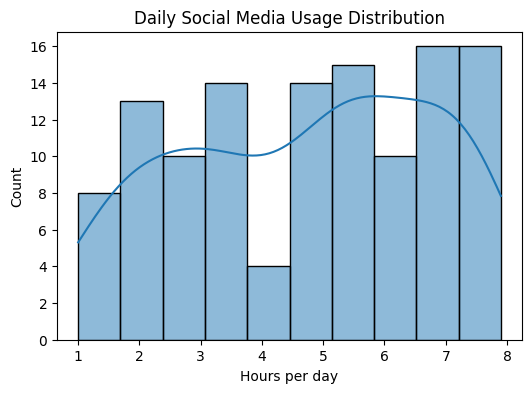

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['daily_usage_hours'], bins=10, kde=True)
plt.title("Daily Social Media Usage Distribution")
plt.xlabel("Hours per day")
plt.show()

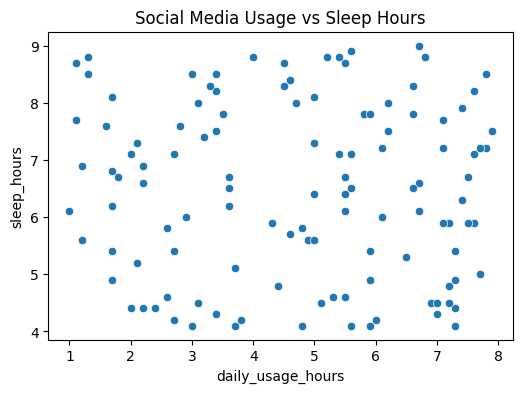

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='daily_usage_hours', y='sleep_hours', data=df)
plt.title("Social Media Usage vs Sleep Hours")
plt.show()

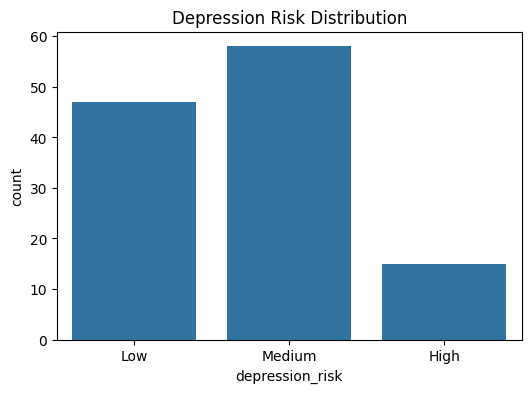

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='depression_risk', data=df)
plt.title("Depression Risk Distribution")
plt.show()

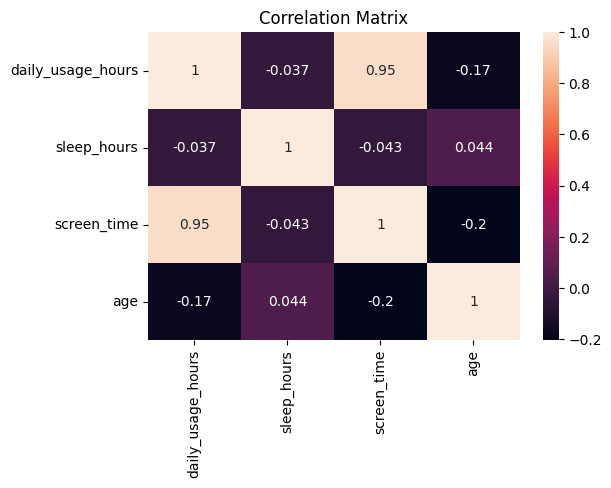

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['daily_usage_hours','sleep_hours','screen_time','age']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [19]:
X = df[['daily_usage_hours','sleep_hours','screen_time','age']]
y = df['depression_risk']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [22]:
predictions = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9583333333333334


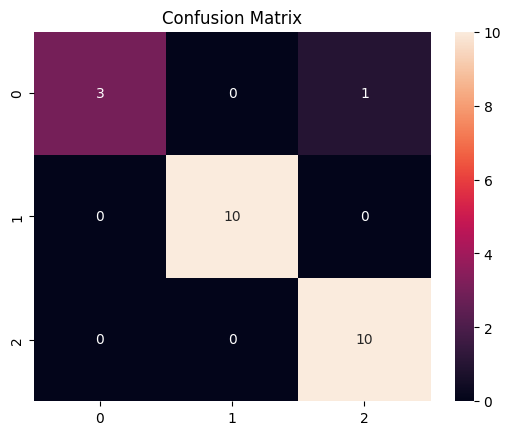

In [24]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [25]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

        High       1.00      0.75      0.86         4
         Low       1.00      1.00      1.00        10
      Medium       0.91      1.00      0.95        10

    accuracy                           0.96        24
   macro avg       0.97      0.92      0.94        24
weighted avg       0.96      0.96      0.96        24

